In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


In [152]:
#Oppgave 1. Nedenfor henter vi ut URL, for å kunne hente inn dataene fra grocery_dataset.csv filen.

# lager dataframes ut av dataene som vi kaller grc_df. og bruker panda importen til å lese ut. 

url = "Grocery_dataset.csv"

grc_df = pd.read_csv(url)

#printer de 10 første og siste radene
display(grc_df.head(10))

display(grc_df.tail(10))


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
4990,FDE46,18.60,Low Fat,0.015859,Snack Foods,152.9366,OUT017,2007,NaN,Tier 2,Supermarket Type1,453.4098
4991,NCQ53,17.60,Low Fat,0.018905,Health and Hygiene,234.6590,OUT046,1997,Small,Tier 1,Supermarket Type1,8508.9240
4992,NCN42,20.25,Low Fat,0.014281,Household,148.0418,OUT018,2009,Medium,Tier 3,Supermarket Type2,1177.1344
4993,DRH11,5.98,Low Fat,0.075675,Hard Drinks,53.3614,OUT049,1999,Medium,Tier 1,Supermarket Type1,331.5684
4994,NCI42,18.75,Low Fat,0.010382,Household,207.8954,OUT049,1999,Medium,Tier 1,Supermarket Type1,2292.3494
4995,FDT07,5.82,Regular,0.077476,Fruits and Vegetables,255.3330,OUT045,2002,NaN,Tier 2,Supermarket Type1,4870.3270
4996,DRL60,8.52,Low Fat,0.027059,Soft Drinks,153.3682,OUT046,1997,Small,Tier 1,Supermarket Type1,914.8092
4997,FDG20,15.50,Regular,0.126200,Fruits and Vegetables,178.4028,OUT018,2009,Medium,Tier 3,Supermarket Type2,1239.7196
4998,FDF56,16.70,Regular,0.119462,Fruits and Vegetables,182.7976,OUT046,1997,Small,Tier 1,Supermarket Type1,1810.9760
4999,FDV33,9.60,Regular,0.027455,Snack Foods,258.1304,OUT018,2009,Medium,Tier 3,Supermarket Type2,2324.9736


In [153]:
grc_df.head

<bound method NDFrame.head of      Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0              FDA15         9.30          Low Fat         0.016047   
1              DRC01         5.92          Regular         0.019278   
2              FDN15        17.50          Low Fat         0.016760   
3              FDX07        19.20          Regular         0.000000   
4              NCD19         8.93          Low Fat         0.000000   
...              ...          ...              ...              ...   
4995           FDT07         5.82          Regular         0.077476   
4996           DRL60         8.52          Low Fat         0.027059   
4997           FDG20        15.50          Regular         0.126200   
4998           FDF56        16.70          Regular         0.119462   
4999           FDV33         9.60          Regular         0.027455   

                  Item_Type  Item_MRP Outlet_Identifier  \
0                     Dairy  249.8092            OUT049   

In [154]:
#sjekker om hvor mange tomme verdier det finnes i hver kolonne, ser at vi får 2 kolonner med flere hundre tilfeller der rader er tomme.
#  dette må vi håndtere. 

grc_df.isna().sum()


Item_Identifier                 0
Item_Weight                   818
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1439
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [155]:
weight_by_item = grc_df.groupby("Item_Identifier")["Item_Weight"].median()

grc_df["Item_Weight"] = grc_df["Item_Weight"].fillna(
    grc_df["Item_Identifier"].map(weight_by_item)
)

# Remove the few rows where the product has no known weight
grc_df.dropna(subset=["Item_Weight"], inplace=True)

grc_df["Item_Weight"].isna().sum()

np.int64(0)

In [156]:
#Setter alle outlet size kolonner som er null-valued til "unknown" ettersom vi ikke kan tippe på low medium eller high.
# det er også for mange tilfeller, til at vi sletter alle radene hvor NaN dukker opp. 
grc_df["Outlet_Size"] = grc_df["Outlet_Size"].fillna("Unknown")

In [157]:
grc_df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [158]:
display(grc_df.head())

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Unknown,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [159]:
outlet_counts = grc_df["Outlet_Size"].value_counts()
print(outlet_counts)

unique_outlet_sizes = grc_df["Outlet_Size"].nunique()
print(unique_outlet_sizes)

print("Outlet size with maximum occurrences:",
      outlet_counts.idxmax(),
      "-", outlet_counts.max())


print("Outlet size with the least occurrences:",
      outlet_counts.idxmin(),
      "-", outlet_counts.min())

Outlet_Size
Medium     1580
Unknown    1439
Small      1388
High        558
Name: count, dtype: int64
4
Outlet size with maximum occurrences: Medium - 1580
Outlet size with the least occurrences: High - 558


In [160]:
print("Number of unique types:",
      grc_df["Item_Fat_Content"].nunique())

print("Unique types:",
      grc_df["Item_Fat_Content"].unique())

#ser at Low fat, LF og lowfat regnes som 3 ulike og Reg og regular. Dette må ordnes. slik at de konverteres og telles som det samme.
#først da blir data korrekt. 

#Benytter oss av Replace metoden.
grc_df["Item_Fat_Content"] = grc_df["Item_Fat_Content"].replace({
    "low fat" : "Low Fat",
    "LF" : "Low Fat",
    "reg" : "Regular"
})
#kontrollerer at det har blitt riktig!

print("Number of unique types after cleaning:",
      grc_df["Item_Fat_Content"].nunique())

print("Types after cleaning:",
      grc_df["Item_Fat_Content"].unique())

Number of unique types: 5
Unique types: <StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str
Number of unique types after cleaning: 2
Types after cleaning: <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str


In [161]:
Grc_new_df = grc_df.drop(
    columns=grc_df.columns[[0, 6]]
)

In [162]:
print(grc_df.columns[[0, 6]])
print(Grc_new_df.columns)
print(Grc_new_df.shape)

Index(['Item_Identifier', 'Outlet_Identifier'], dtype='str')
Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')
(4965, 10)


In [163]:
SupType_1 = Grc_new_df[Grc_new_df["Outlet_Type"]== "Supermarket Type1"].copy()

SupType_2 = Grc_new_df[Grc_new_df["Outlet_Type"]== "Supermarket Type2"].copy()

print(SupType_1["Outlet_Type"].unique())
print(SupType_2["Outlet_Type"].unique())

print("SupType_1 shape:", SupType_1.shape)
print("SupType_2 shape:", SupType_2.shape)


<StringArray>
['Supermarket Type1']
Length: 1, dtype: str
<StringArray>
['Supermarket Type2']
Length: 1, dtype: str
SupType_1 shape: (3328, 10)
SupType_2 shape: (526, 10)


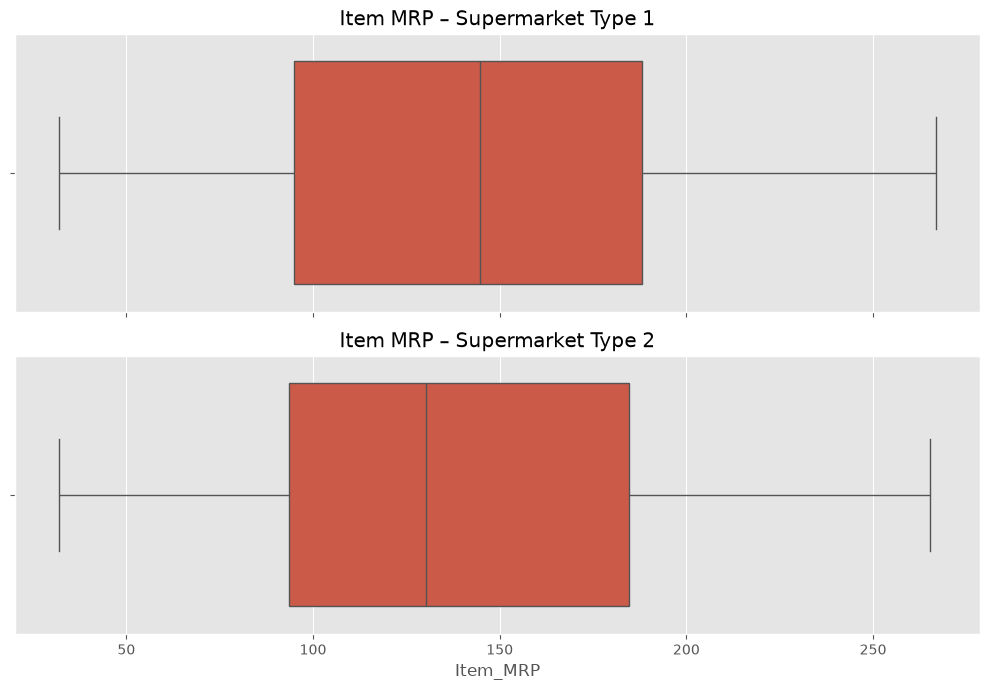

Median MRP for Supermarket Type 1: 144.7457
Median MRP for Supermarket Type 2: 130.18099999999998


In [164]:
# Use ggplot style
plt.style.use("ggplot")

# Create 2 rows and 1 column
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True
)

# Supermarket Type 1
sns.boxplot(
    data=SupType_1,
    x="Item_MRP",
    ax=axes[0]
)

axes[0].set_title("Item MRP – Supermarket Type 1")

# Supermarket Type 2
sns.boxplot(
    data=SupType_2,
    x="Item_MRP",
    ax=axes[1]
)

axes[1].set_title("Item MRP – Supermarket Type 2")

plt.tight_layout()
plt.show()

median_type_1 = SupType_1["Item_MRP"].median()
median_type_2 = SupType_2["Item_MRP"].median()

print("Median MRP for Supermarket Type 1:", median_type_1)
print("Median MRP for Supermarket Type 2:", median_type_2)

In [165]:
summary = pd.DataFrame({
    "Supermarket Type 1": SupType_1["Item_MRP"].describe()[
        ["min", "25%", "50%", "75%", "max"]
    ],
    "Supermarket Type 2": SupType_2["Item_MRP"].describe()[
        ["min", "25%", "50%", "75%", "max"]
    ]
})

display(summary)

,Supermarket Type 1,Supermarket Type 2
min,31.95580,31.89000
25%,95.02455,93.56990
50%,144.74570,130.18100
75%,188.03190,184.56935
max,266.88840,265.18840


In [166]:
# Concatenate the two DataFrames
Grc_Concat_df = pd.concat(
    [SupType_1, SupType_2],
    ignore_index=True
)

# Sort from lowest to highest sales
Grc_Concat_df = Grc_Concat_df.sort_values(
    by="Item_Outlet_Sales",
    ascending=True
).reset_index(drop=True)

# Display the first rows
display(
    Grc_Concat_df[
        ["Item_Outlet_Sales", "Outlet_Location_Type", "Outlet_Type"]
    ].head()
)

lowest_sales_location = Grc_Concat_df.iloc[0]["Outlet_Location_Type"]

print("Outlet location type with the lowest sales:",
      lowest_sales_location)

,Item_Outlet_Sales,Outlet_Location_Type,Outlet_Type
0,73.2380,Tier 3,Supermarket Type1
1,75.9012,Tier 3,Supermarket Type2
2,78.5644,Tier 3,Supermarket Type2
3,99.8700,Tier 2,Supermarket Type1
4,101.8674,Tier 1,Supermarket Type1


Outlet location type with the lowest sales: Tier 3


In [167]:
Grc_Concat_df = Grc_Concat_df.set_index(
    ["Outlet_Size", "Outlet_Location_Type"]
)

Grc_Concat_df = Grc_Concat_df.sort_index()

Grc_Concat_df.head()

Item_Weight Item_Fat_Content  \
Outlet_Size Outlet_Location_Type                                 
High        Tier 3                     20.500          Low Fat   
            Tier 3                      7.220          Regular   
            Tier 3                      7.935          Low Fat   
            Tier 3                     19.250          Low Fat   
            Tier 3                     11.800          Regular   

                                  Item_Visibility     Item_Type  Item_MRP  \
Outlet_Size Outlet_Location_Type                                            
High        Tier 3                       0.143164     Household   34.9190   
            Tier 3                       0.038289  Baking Goods   64.7510   
            Tier 3                       0.017142         Dairy   50.0350   
            Tier 3                       0.101689         Dairy   54.6956   
            Tier 3                       0.076657   Snack Foods   32.3558   

                                  Outlet_Establishment_Year  \
Outlet_Size Outlet_Location_Type                              
High        Tier 3                                     1987   
            Tier 3                                     1987   
            Tier 3                                     1987   
            Tier 3                                     1987   
            Tier 3                                     1987   

                                        Outlet_Type  Item_Outlet_Sales  
Outlet_Size Outlet_Location_Type                                        
High        Tier 3                Supermarket Type1            73.2380  
            Tier 3                Supermarket Type1           126.5020  
            Tier 3                Supermarket Type1           149.8050  
            Tier 3                Supermarket Type1           163.7868  
            Tier 3                Supermarket Type1           169.7790

In [175]:
# Divide Item_Weight into 10 equal-width buckets
Grc_Concat_df["Weight_Bucket"] = pd.cut(
    Grc_Concat_df["Item_Weight"],
    bins=10,
    include_lowest=True
)

weight_statistics = (
    Grc_Concat_df
    .groupby("Weight_Bucket", observed=False)
    .agg(
        Mean_Weight=("Item_Weight", "mean"),
        Minimum_Weight=("Item_Weight", "min"),
        Maximum_Weight=("Item_Weight", "max"),
        Number_of_Items=("Item_Weight", "count")
    )
    .round(2)
)

display(weight_statistics)

,Mean_Weight,Minimum_Weight,Maximum_Weight,Number_of_Items
Weight_Bucket,,,,
"(4.537, 6.234]",5.62,4.56,6.22,253
"(6.234, 7.914]",7.12,6.24,7.90,476
"(7.914, 9.594]",8.76,7.93,9.50,450
"(9.594, 11.273]",10.34,9.60,11.15,362
"(11.273, 12.952]",12.08,11.30,12.85,419
"(12.952, 14.632]",13.72,13.00,14.60,352
"(14.632, 16.312]",15.50,14.65,16.25,410
"(16.312, 17.991]",17.17,16.35,17.85,408
"(17.991, 19.671]",18.84,18.00,19.60,396
